# Airline Tweet Sentiment Analysis - Natural Language Processing (NLP)

## Project Objective

The objective of this project is to analyze and compare public sentiment toward major U.S. airlines by applying both traditional NLP techniques and modern Large Language Model (LLM)–based approaches to Twitter data.

- Collect and preprocess airline-related tweets using standard NLP techniques, such as text cleaning, tokenization, and normalization.
- Perform sentiment classification (positive, negative, and neutral) using **machine learning models** built with vectorization techniques (e.g., TF-IDF) and **transformer-based models from the Hugging Face ecosystem**.
- Leverage Large Language Models through prompt-based sentiment analysis using LangChain to evaluate zero-shot and few-shot classification performance.
- Compare the performance of traditional machine learning models, transformer-based models, and LLM-driven approaches using evaluation metrics such as accuracy, precision, recall, F1-score, confusion matrices, exact match, consistency, hallucination, and prompt sensitivity.
- Analyze and visualize sentiment distributions across different U.S. airlines to uncover trends, customer pain points, and perception differences.
- Derive actionable insights by comparing model outputs and observations to assess the effectiveness, strengths, and limitations of each NLP approach in real-world sentiment analysis tasks.

## Dataset Description

| **Column Name**                | **Description**                                           |
| ------------------------------ | --------------------------------------------------------- |
| `tweet_id`                     | Unique identifier for each tweet                          |
| `airline_sentiment`            | Sentiment of the tweet: positive, negative, or neutral    |
| `airline_sentiment_confidence` | Confidence score of the sentiment classification (0 to 1) |
| `negativereason`               | Reason for negative sentiment (if applicable)             |
| `negativereason_confidence`    | Confidence of the negative reason label                   |
| `airline`                      | Name of the airline mentioned in the tweet                |
| `name`                         | Twitter username of the person who posted the tweet       |
| `retweet_count`                | Number of times the tweet has been retweeted              |
| `text`                         | Content of the tweet                                      |
| `tweet_coord`                  | Geolocation coordinates of the tweet (if available)       |
| `tweet_created`                | Timestamp when the tweet was posted                       |
| `tweet_location`               | User-reported location (if available)                     |
| `user_timezone`                | Timezone of the user posting the tweet                    |


## Method 1: Traditional NLP and Machine Learning Approaches

## Import libraries

In [ ]:
# !pip install contractions
# !pip install nltk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re, string, unicodedata
import contractions
from bs4 import BeautifulSoup

import nltk                   ## Import Natural Language Tool-kit
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


from nltk.corpus import stopwords                       # Import stopwords.
from nltk.tokenize import word_tokenize, sent_tokenize  # Import Tokenizer.
from nltk.stem.wordnet import WordNetLemmatizer         # Import Lemmatizer.

import warnings
warnings.filterwarnings('ignore')


## Load data

In [ ]:
data = pd.read_csv(r'/content/Tweets.csv')
data.head(3).T

,0,1,2
tweet_id,570306133677760513,570301130888122368,570301083672813571
airline_sentiment,neutral,positive,neutral
airline_sentiment_confidence,1.0,0.3486,0.6837
negativereason,NaN,NaN,NaN
negativereason_confidence,NaN,0.0,NaN
airline,Virgin America,Virgin America,Virgin America
airline_sentiment_gold,NaN,NaN,NaN
name,cairdin,jnardino,yvonnalynn
negativereason_gold,NaN,NaN,NaN
retweet_count,0,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [ ]:
# missing data
data.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [ ]:
data.isnull().sum()/len(data)*100

tweet_id                         0.000000
airline_sentiment                0.000000
airline_sentiment_confidence     0.000000
negativereason                  37.308743
negativereason_confidence       28.128415
airline                          0.000000
airline_sentiment_gold          99.726776
name                             0.000000
negativereason_gold             99.781421
retweet_count                    0.000000
text                             0.000000
tweet_coord                     93.039617
tweet_created                    0.000000
tweet_location                  32.329235
user_timezone                   32.923497
dtype: float64

All tweets contain text, so missing values in other columns are not treated for this analysis.

## EDA - Exploratory Data Analysis

### Percentage of tweets by Airline Companies

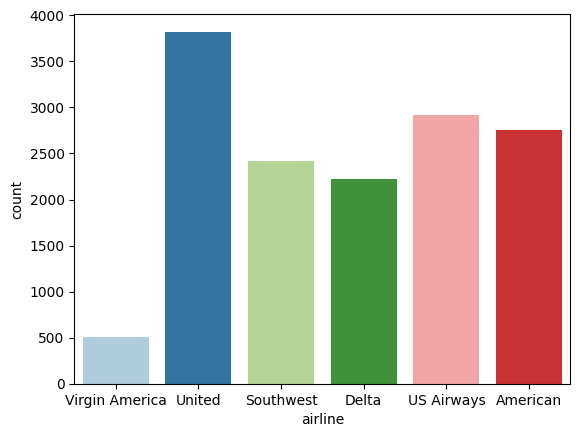

In [ ]:
sns.countplot(data=data, x='airline', palette = 'Paired')
plt.show()

In [ ]:
print("Total number of tweets:", data['text'].count())


Total number of tweets: 14640


- United Airlines has the highest number of tweets, followed by US Airways.

### Distribution of Sentiments across all tweets

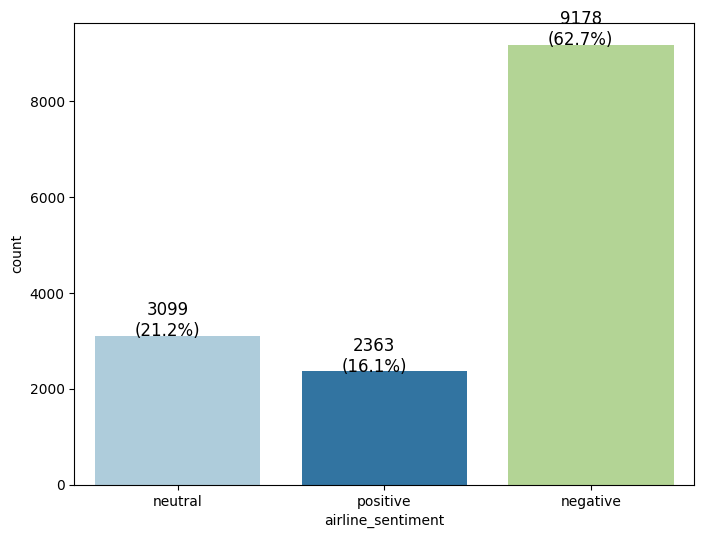

In [ ]:
plt.subplots(figsize=(8,6))
ax = sns.countplot(data=data,
                   x='airline_sentiment',
                   palette ='Paired')

# Calculate total count for percentage calculation
total = len(data)

# Annotate bars with count and percentage
for p in ax.patches:
    count = int(p.get_height())                 # Get the height of each bar (count)
    percentage = f'{100 * count / total:.1f}%'  # Calculate the percentage
    x = p.get_x() + p.get_width() / 2 - 0.05    # Adjust x position for better alignment
    y = p.get_height() + 0.5                    # Adjust y position to place above the bar
    ax.annotate(f'{count}\n({percentage})', (x, y), size=12, ha='center')  # Annotate the plot

plt.show()


- Majority of tweets are `negative` (63%), followed by neutral tweets (21%), and then the positive tweets (16%)

In [ ]:
# Negative class sample
sel_neg = data['airline_sentiment']=='negative'
data[sel_neg]['text'].sample(5).tolist()

["@USAirways @AmericanAir as a Gold Dividends member, why can't I get anyone on phone to handle my Cancelled Flighted American flight tonight 😡",
 '@united already did that at the airport and 12 hrs Late Flightr its still not here! you guys are really killing me today. trying to stay positive..',
 '@SouthwestAir 25 year customer but I am 6 3 and those lost 2 or 3 inches really hurt  every time the person in front shifts he raps my knees',
 '@SouthwestAir All I requested was a refund of my Reward Points that I used to purchase the flight and he refused.',
 '@AmericanAir an hour now waiting on the phone for US Air help. 10 hours waiting at the airport yesterday. Love the service guys.']

In [ ]:
# positive class sample
sel_pos = data['airline_sentiment']=='positive'
data[sel_pos]['text'].sample(5).tolist()

['@USAirways Wow unbelievable how you treat your customers at Puerto Rico airport! 👍',
 "@AmericanAir that's ok, thanks for letting me know. Appreciate all the responses.",
 '@SouthwestAir no worries. We got thru eventually. I was just curious. Best of luck to you dealing with the weather!',
 '@JetBlue @L_Burley11 -- the best!!!',
 '@JetBlue Thank you for the JetBlue Credit. Nice save :-)']

In [ ]:
# neutral
sel_net = data['airline_sentiment']=='neutral'
data[sel_net]['text'].sample(5).tolist()


['@VirginAmerica to start 5xweekly #A319 flights from to #Dallas @DallasLoveField #Austin on 28APR #avgeek',
 '@united I have a LH return business ticket from Den to Fra.If I fly domestic with you,bag can be checked through to Fra,no need to claim?',
 '@united Definitely will!',
 "@united My post was just more of disappointment.  I'm a frequent United flyer, it was a simple ??.  1 bad apple doesn't spoil the bunch.",
 '@USAirways I was supposed to be on flight 1861 from Charlotte to RDU @ 8:20pm yesterday. Is the same flight scheduled for departure tonight?']

### Distribution of Sentiments of Tweets for each airline

In [ ]:
airline_sentiment_grp = data.groupby(['airline', 'airline_sentiment']).airline_sentiment.count().unstack()
airline_sentiment_grp

airline_sentiment,negative,neutral,positive
airline,,,
American,1960,463,336
Delta,955,723,544
Southwest,1186,664,570
US Airways,2263,381,269
United,2633,697,492
Virgin America,181,171,152


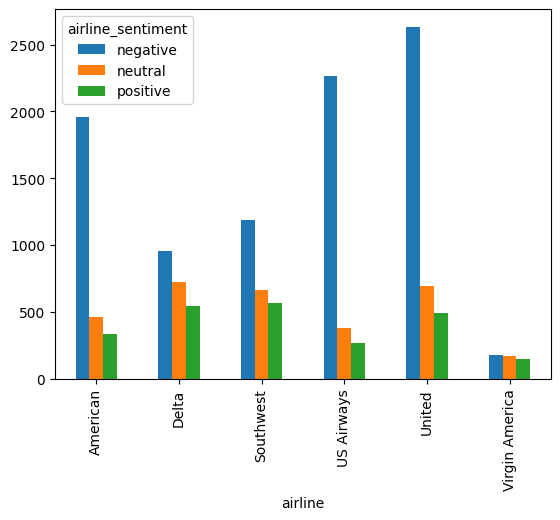

In [ ]:
airline_sentiment_grp.plot(kind='bar')
plt.show()

### Negative reasons

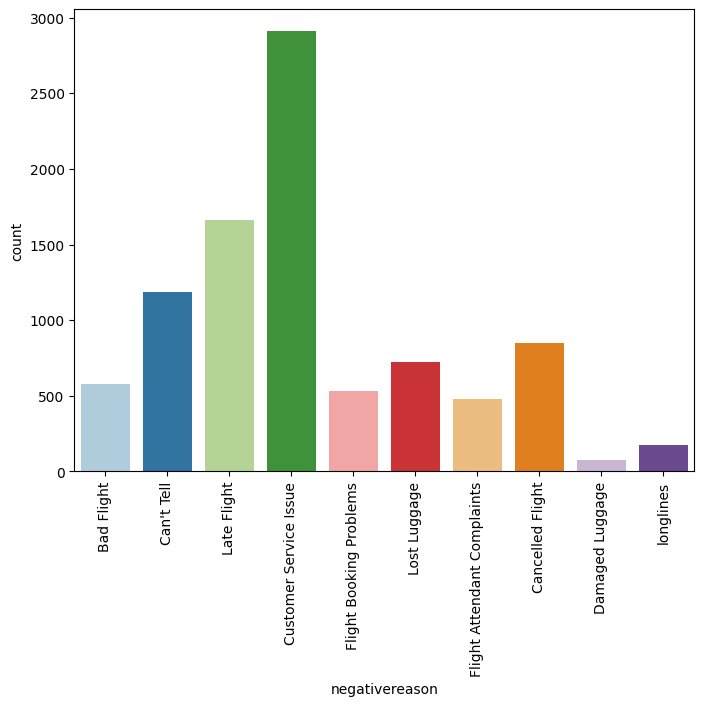

In [ ]:
plt.subplots(figsize=(8,6))

sns.countplot(data=data, x='negativereason', palette ='Paired')
# Rotate the x-tick labels
plt.xticks(rotation=90)
plt.show()

- Among all negative reasons, customer service issues account for the majority of negative sentiments

## Data Preprocessing

In [ ]:
stop_words = stopwords.words('english')

In [ ]:
customlist = ['not', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
        "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',
        "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn',
        "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

In [ ]:
stop_words = list(set(stop_words) - set(customlist))
stop_words

['for',
 'if',
 'with',
 'does',
 'am',
 "i'd",
 'doing',
 'a',
 'other',
 'she',
 'through',
 'very',
 'most',
 "i've",
 'aren',
 's',
 'out',
 'down',
 'were',
 'after',
 'off',
 'which',
 'such',
 'from',
 'me',
 'myself',
 'more',
 'themselves',
 'what',
 "you'll",
 'm',
 'be',
 't',
 'this',
 'once',
 'can',
 'same',
 'below',
 'is',
 'my',
 'couldn',
 'herself',
 'are',
 'few',
 'above',
 'any',
 'both',
 'all',
 'at',
 'there',
 'in',
 'about',
 'the',
 'i',
 "we're",
 'should',
 'or',
 'them',
 'has',
 'of',
 'ain',
 'under',
 'over',
 'these',
 'while',
 'until',
 'between',
 'to',
 'him',
 'and',
 'but',
 'your',
 "you're",
 're',
 'itself',
 'have',
 'been',
 'only',
 'own',
 'up',
 "we'll",
 "he'll",
 "aren't",
 "they've",
 'so',
 'nor',
 'as',
 'before',
 'an',
 'ours',
 "she's",
 "you'd",
 'did',
 "i'll",
 'being',
 'will',
 "don't",
 'd',
 "she'd",
 'their',
 "she'll",
 'o',
 'because',
 "i'm",
 "they'll",
 'each',
 'his',
 'where',
 'into',
 "he's",
 "should've",
 'by',

### Preprocessing Functions

In [ ]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # 2. Expand contractions
    text = contractions.fix(text)

    # 3. Remove special characters, numbers, and punctuations
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Normalize unicode characters
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    # 5. Tokenize
    tokens = word_tokenize(text.lower())

    # 6. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 7. Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 8. Join tokens back to string
    clean_text = ' '.join(tokens)

    return clean_text


In [ ]:
# Apply Preprocessing to Your Dataset
data['text'] = data['text'].apply(clean_text)
data['text'].head()

# data['text'] = data.apply(lambda row: clean_text(row['text']), axis=1)
# data.head()

0                          virginamerica dhepburn said
1    virginamerica plus added commercial experience...
2    virginamerica not today must mean need take an...
3    virginamerica really aggressive blast obnoxiou...
4                   virginamerica really big bad thing
Name: text, dtype: object

### Word Cloud for negative tweets

In [ ]:
# !pip install wordcloud
from wordcloud import WordCloud,STOPWORDS

neg_df = data[data['airline_sentiment']=='negative'] # filtered for negative sentiments
words = ' '.join(neg_df['text']).split() #combines all the tweets (stored in the column'text') into a single string, where each tweet is separated by space

[('flight', 3338), ('not', 3312), ('united', 2883), ('usairways', 2374), ('americanair', 2104), ('southwestair', 1213), ('hour', 1098), ('jetblue', 1050), ('get', 1011), ('cancelled', 920), ('customer', 773), ('service', 763), ('time', 731), ('bag', 654), ('help', 613), ('hold', 610), ('plane', 589), ('u', 520), ('call', 496), ('would', 493)]


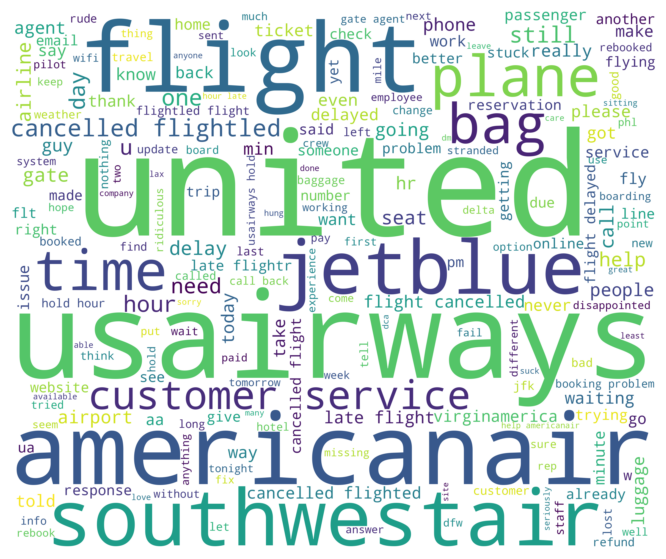

In [ ]:
# Top 20 most frequent words
from collections import Counter

word_freq = Counter(words)
print(word_freq.most_common(20))

# Plot word cloud (optional)
wordcloud = WordCloud(stopwords=STOPWORDS, #exclude common stopwords
                     background_color=  'white',
                     width=3000,
                     height= 2500).generate(' '.join(words))


plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


## Model Building

#### Vectorization - converts text data to numbers

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer # to convert a collection of text docs into a matrix of token counts

In [ ]:
data['text'].sample(2)

10843    usairways yes go pick pay cab ride rude employ...
6898     jetblue datingrev mco lag two hour delay sitti...
Name: text, dtype: object

In [ ]:
Count_vec = CountVectorizer(max_features=5000) #keeping only 5000 featueres
data_features = Count_vec.fit_transform(data['text'])

`max_features`: signifies the unique number of features (i.e., unique words of tokens) --> 5000

 - Keeping the limit to 5000, it ensures that only `top` 5000 most fequent words are kept in the model

In [ ]:
data_features = data_features.toarray()

In [ ]:
print(data_features.shape)
print(data['text'].shape)

(14640, 5000)
(14640,)


In [ ]:
### Output the results
print("Vocabulary:", Count_vec.get_feature_names_out().tolist())


Vocabulary: ['aa', 'aaba', 'aadfw', 'aadv', 'aadvantage', 'aafail', 'aal', 'aano', 'aarp', 'ab', 'abandoned', 'abc', 'abcnetwork', 'ability', 'able', 'aboard', 'abq', 'abroad', 'absolute', 'absolutely', 'absurd', 'abused', 'abysmal', 'ac', 'accept', 'acceptable', 'accepted', 'accepting', 'access', 'accident', 'accidentally', 'accommodate', 'accommodated', 'accommodating', 'accommodation', 'accomplished', 'according', 'accordingly', 'account', 'accountability', 'accurate', 'acknowledge', 'across', 'act', 'action', 'active', 'activitiesprevention', 'activity', 'actual', 'actually', 'ad', 'adam', 'add', 'added', 'adding', 'addition', 'additional', 'addl', 'address', 'addressed', 'addtl', 'admiral', 'admit', 'adopting', 'advance', 'advantage', 'advertise', 'advertising', 'advice', 'advise', 'advised', 'advising', 'advisory', 'aerojobmarket', 'affect', 'affected', 'affecting', 'affiliate', 'afford', 'affordable', 'afraid', 'afterall', 'afternoon', 'age', 'agency', 'agent', 'aggressive', 'ag

### Train test split

In [ ]:
X = data_features #training features
y = data.airline_sentiment #training target

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

### Using random forest model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=10)

### Training the model
rf_trained = rf.fit(X_train,y_train)

### Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
def model_metrics(y_true, y_pred,average='weighted'):

    print(f"Model: {rf_trained.__class__.__name__}\n")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average=average, zero_division=1):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, average=average, zero_division=1):.4f}")
    print(f"F1_score:  {f1_score(y_true, y_pred, average=average, zero_division=1):.4f}")
    print(f"\nConfusion matrix:\n{confusion_matrix(y_true, y_pred)}")
    print(f"\nClassification report:\n{classification_report(y_true, y_pred)}")

In [ ]:
y_pred = rf_trained.predict(X_test)

In [ ]:
model_metrics(y_test,y_pred)

Model: RandomForestClassifier

Accuracy:  0.7623
Precision: 0.7536
Recall:    0.7623
F1_score:  0.7533

Confusion matrix:
[[2534  216   64]
 [ 380  443   61]
 [ 201  122  371]]

Classification report:
              precision    recall  f1-score   support

    negative       0.81      0.90      0.85      2814
     neutral       0.57      0.50      0.53       884
    positive       0.75      0.53      0.62       694

    accuracy                           0.76      4392
   macro avg       0.71      0.65      0.67      4392
weighted avg       0.75      0.76      0.75      4392



#### Observations:

- The Random Forest model achieved an accuracy of 75.6%. It performs best on negative tweets (precision 0.81, recall 0.90), while neutral (precision 0.55, recall 0.48) and positive tweets (precision 0.74, recall 0.53) are predicted less accurately.
-  The confusion matrix indicates some misclassification of neutral and positive tweets as negative, likely due to dataset imbalance.
-  Overall, the model effectively captures negative sentiment but could be improved for neutral and positive classes.

## Save model


In [ ]:
import joblib
joblib.dump(rf_trained,'rf_trained.pkl')
joblib.dump(Count_vec, 'Count_vec.pkl')

['Count_vec.pkl']

## Deployment

In [ ]:
import gradio as gr
import re
import string
import unicodedata
from bs4 import BeautifulSoup
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import joblib

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Stopwords & Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Clean text function (from your code)
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # 2. Expand contractions
    text = contractions.fix(text)

    # 3. Remove special characters, numbers, and punctuations
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Normalize unicode characters
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    # 5. Tokenize
    tokens = word_tokenize(text.lower())

    # 6. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 7. Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 8. Join tokens back to string
    return ' '.join(tokens)

# Load trained model and vectorizer
model = joblib.load('rf_trained.pkl')
Count_vec = joblib.load('Count_vec.pkl')


# Prediction function for Gradio
def predict_sentiment(tweet):
    cleaned = clean_text(tweet)
    vect = Count_vec.transform([cleaned]).toarray()
    pred = model.predict(vect)[0]
    return pred

# Example tweets
examples = [
    "I love flying with Delta! Great service.",
    "United Airlines delayed my flight again...",
    "My experience with American Airlines was okay."
]

# Gradio interface
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter a tweet here..."),
    outputs="text",
    title="US Airline Tweet Sentiment Analysis",
    description="Enter a tweet about a US airline and get the predicted sentiment: Positive, Neutral, or Negative.",
    examples=examples,
    cache_examples=False,
)

if __name__ == "__main__":
    iface.launch(share=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.



# Method 1: Traditional NLP and Machine Learning Approaches

### **Conclusion**
- Public sentiment toward US airlines using Natural Language Processing (NLP) techniques on Twitter data was conducted.
- The workflow included data exploration, preprocessing, feature extraction, machine learning model building, evaluation, and deployment
- Majority of tweets were negative (63%), with customer service issues as the main concern.
- Random Forest model achieved ~76% accuracy in classifying tweets into positive, neutral, and negative.
- Deployed a Gradio app for real-time sentiment prediction, enabling airlines to monitor feedback and improve customer experience.

### Recommenation
Airlines should prioritize improving customer service to enhance passenger satisfaction and retain loyalty.


# Method2 : Prompt-Based LLM Sentiment Analysis

## Load data

In [2]:
import pandas as pd
import re

df = pd.read_csv(r'/content/Tweets.csv')

df = df[['text', 'airline_sentiment']]
df.head()


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [3]:
# cleaning function

def minimal_clean(text):
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = text.replace("\n", " ")
    return text.strip()


In [4]:
df['clean_text'] = df['text'].apply(minimal_clean)

In [5]:
# sample data
df_sample = df.sample(200, random_state=42)


## Hugging Face model

In [6]:
from transformers import pipeline

hf_pipeline = pipeline(
    task="text-generation",
    model="google/flan-t5-base",
    max_length=256,
   do_sample = False
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCau

## LangChain wrapper

In [ ]:
# !pip install -q langchain-experimental langchain-community
# !pip install langchain langchain-huggingface transformers

In [7]:
from langchain_huggingface.llms import HuggingFacePipeline

# wrap your HF transformers pipeline
llm = HuggingFacePipeline(pipeline=hf_pipeline)


## Prompt Engineering

### Zero shot

In [8]:
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain

zero_shot_prompt = PromptTemplate(
    input_variables=["tweet"],
    template="""
Classify the sentiment of the following airline tweet as
Positive, Neutral, or Negative.

Tweet: {tweet}
Sentiment:
"""
)

zero_shot_chain = LLMChain(llm=llm, prompt=zero_shot_prompt)


## Few-shot prompt

In [9]:
few_shot_prompt = PromptTemplate(
    input_variables=["tweet"],
    template="""
You are an expert in airline customer sentiment analysis.

Example 1:
Tweet: Thanks Delta for the smooth flight!
Sentiment: Positive

Example 2:
Tweet: Flight delayed but staff was helpful.
Sentiment: Neutral

Example 3:
Tweet: United Airlines lost my baggage.
Sentiment: Negative

Now classify:
Tweet: {tweet}
Sentiment:
"""
)

few_shot_chain = LLMChain(llm=llm, prompt=few_shot_prompt)


## Run LLM on Dataset

In [10]:
# Normalize LLM outputs
def clean_output(text):
    text = text.lower()
    if "positive" in text:
        return "positive"
    elif "negative" in text:
        return "negative"
    else:
        return "neutral"

# Create prompts
prompts = [few_shot_prompt.format(tweet=tweet) for tweet in df_sample['text']]

# Run HF pipeline in batch
outputs = hf_pipeline(prompts, batch_size=16)

# Safe extraction for nested output
def extract_text(out):
    if isinstance(out, list):
        if len(out) > 0:
            return extract_text(out[0])  # recursively unwrap
        else:
            return ""
    elif isinstance(out, dict) and "generated_text" in out:
        return out["generated_text"]
    elif isinstance(out, str):
        return out
    else:
        return str(out)

# Clean outputs
predictions = [clean_output(extract_text(out)) for out in outputs]

# Add predictions to DataFrame
df_sample['llm_prediction'] = predictions

df_sample.head()


,text,airline_sentiment,clean_text,llm_prediction
4794,@SouthwestAir you're my early frontrunner for ...,positive,@SouthwestAir you're my early frontrunner for ...,positive
10480,@USAirways how is it that my flt to EWR was Ca...,negative,@USAirways how is it that my flt to EWR was Ca...,positive
8067,@JetBlue what is going on with your BDL to DCA...,negative,@JetBlue what is going on with your BDL to DCA...,positive
8880,@JetBlue do they have to depart from Washingto...,neutral,@JetBlue do they have to depart from Washingto...,positive
8292,@JetBlue I can probably find some of them. Are...,negative,@JetBlue I can probably find some of them. Are...,positive


In [14]:
# pred
zero_shot_preds = []
few_shot_preds = []
# Zero-shot prompts
zs_prompts = [zero_shot_prompt.format(tweet=tweet) for tweet in df_sample['text']]

# Few-shot prompts
fs_prompts = [few_shot_prompt.format(tweet=tweet) for tweet in df_sample['text']]

# Adjust batch_size depending on GPU memory
zs_outputs = hf_pipeline(zs_prompts, batch_size=16, do_sample=False)
fs_outputs = hf_pipeline(fs_prompts, batch_size=16, do_sample=False)

def extract_text(out):
    if isinstance(out, list):
        if len(out) > 0:
            return extract_text(out[0])  # unwrap nested lists
        else:
            return ""
    elif isinstance(out, dict) and "generated_text" in out:
        return out["generated_text"]
    elif isinstance(out, str):
        return out
    else:
        return str(out)

# normalize output

zero_shot_preds = [clean_output(extract_text(out)) for out in zs_outputs]
few_shot_preds = [clean_output(extract_text(out)) for out in fs_outputs]


# predictions
df_sample['zero_shot_pred'] = zero_shot_preds
df_sample['few_shot_pred'] = few_shot_preds

df_sample.head()


Passing `generation_config` together with generation-related arguments=({'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


,text,airline_sentiment,clean_text,llm_prediction,zero_shot_pred,few_shot_pred
4794,@SouthwestAir you're my early frontrunner for ...,positive,@SouthwestAir you're my early frontrunner for ...,positive,positive,positive
10480,@USAirways how is it that my flt to EWR was Ca...,negative,@USAirways how is it that my flt to EWR was Ca...,positive,positive,positive
8067,@JetBlue what is going on with your BDL to DCA...,negative,@JetBlue what is going on with your BDL to DCA...,positive,positive,positive
8880,@JetBlue do they have to depart from Washingto...,neutral,@JetBlue do they have to depart from Washingto...,positive,positive,positive
8292,@JetBlue I can probably find some of them. Are...,negative,@JetBlue I can probably find some of them. Are...,positive,positive,positive


In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = df_sample['airline_sentiment']
y_pred = df_sample['llm_prediction']

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))


Accuracy: 0.195
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       121
     neutral       0.00      0.00      0.00        40
    positive       0.20      1.00      0.33        39

    accuracy                           0.20       200
   macro avg       0.07      0.33      0.11       200
weighted avg       0.04      0.20      0.06       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## LLM based metrics

In [26]:
# Exact Match

exact_match = sum(y_true == y_pred) / len(y_true)
exact_match

0.195

In [27]:
#prompt sensitivity
print("Zero-shot accuracy:", accuracy_score(y_true, zero_shot_preds))
print("Few-shot accuracy:", accuracy_score(y_true, few_shot_preds))

Zero-shot accuracy: 0.195
Few-shot accuracy: 0.195


In [28]:
# Hallucination Rate
# Invalid outputs from LLM.

valid_labels = ["positive", "neutral", "negative"]

hallucinations = [
    p for p in predictions if p not in valid_labels
]

hallucination_rate = len(hallucinations) / len(predictions)
hallucination_rate

0.0

In [29]:
	# Response Consistency
tweet = "United Airlines delayed my flight again."

outputs = [clean_output(few_shot_chain.run(tweet)) for _ in range(5)]
outputs

consistency = outputs.count(outputs[0]) / len(outputs)
consistency

/usr/local/lib/python3.12/dist-packages/langchain_core/_api/deprecation.py:119: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 0.2.0. Use invoke instead.
  warn_deprecated(


1.0

### Observation

| Metric               | Value |
| -------------------- | ----- |
| Exact Match          | 0.195 |
| Response Consistency | 1     |
| Zero-shot Accuracy   | 0.195 |
| Few-shot Accuracy    | 0.195 |
| Hallucination Rate   | 0     |



- The model is deterministic but biased.
- Few-shot or zero-shot prompts are causing the LLM to favor one class heavily.That’s why accuracy is so low even though it never hallucinates.
- Consistency of 1 is misleading. High consistency doesn’t mean high accuracy — it just means the model always predicts the same label.
- No hallucination is good

##  Zero-Shot Sentiment Classification Using Pretrained LLM

In [31]:
from transformers import pipeline

# create a zero-shot classification pipeline
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0
)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [32]:
from transformers import pipeline

texts = df_sample["text"].tolist()

results = classifier(
    texts,
    candidate_labels=["positive", "neutral", "negative"],
    batch_size=16
)



In [33]:
zs_preds = [res["labels"][0] for res in results]

df_sample["zs_pred"] = zs_preds
df_sample.head()


,text,airline_sentiment,clean_text,llm_prediction,zero_shot_pred,few_shot_pred,zs_pred
4794,@SouthwestAir you're my early frontrunner for ...,positive,@SouthwestAir you're my early frontrunner for ...,positive,positive,positive,positive
10480,@USAirways how is it that my flt to EWR was Ca...,negative,@USAirways how is it that my flt to EWR was Ca...,positive,positive,positive,negative
8067,@JetBlue what is going on with your BDL to DCA...,negative,@JetBlue what is going on with your BDL to DCA...,positive,positive,positive,negative
8880,@JetBlue do they have to depart from Washingto...,neutral,@JetBlue do they have to depart from Washingto...,positive,positive,positive,negative
8292,@JetBlue I can probably find some of them. Are...,negative,@JetBlue I can probably find some of them. Are...,positive,positive,positive,neutral


In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = df_sample["airline_sentiment"]
y_pred = df_sample["zs_pred"]


In [35]:
# classical nlp metrics
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))


Accuracy: 0.725
              precision    recall  f1-score   support

    negative       0.85      0.90      0.88       121
     neutral       0.00      0.00      0.00        40
    positive       0.51      0.92      0.66        39

    accuracy                           0.72       200
   macro avg       0.46      0.61      0.51       200
weighted avg       0.62      0.72      0.66       200



#### LLM specific

In [36]:
exact_match = (y_true == y_pred).mean()
exact_match


0.725

In [37]:
tweet = "United Airlines delayed my flight again."

outputs = [
    classifier(tweet, candidate_labels=["positive", "neutral", "negative"])["labels"][0]
    for _ in range(5)
]

consistency = outputs.count(outputs[0]) / len(outputs)

outputs, consistency


(['negative', 'negative', 'negative', 'negative', 'negative'], 1.0)

In [38]:
# Hallucination Rate
valid_labels = ["positive", "neutral", "negative"]

hallucinations = [p for p in y_pred if p not in valid_labels]
hallucination_rate = len(hallucinations) / len(y_pred)

hallucination_rate


0.0

In [39]:
# Prompt sensitivity comparison

In [40]:
from sklearn.metrics import accuracy_score

print(
    "FLAN-T5 few-shot accuracy:",
    accuracy_score(y_true, df_sample["few_shot_pred"])
)
print(
    "BART zero-shot accuracy:",
    accuracy_score(y_true, y_pred)
)


FLAN-T5 few-shot accuracy: 0.195
BART zero-shot accuracy: 0.725


In [41]:
# metrics summary table
import pandas as pd

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Exact Match",
        "Response Consistency",
        "Hallucination Rate"
    ],
    "Value": [
        accuracy_score(y_true, y_pred),
        exact_match,
        consistency,
        hallucination_rate
    ]
})

metrics_table


,Metric,Value
0,Accuracy,0.725
1,Exact Match,0.725
2,Response Consistency,1.000
3,Hallucination Rate,0.000


### observation for LLM based model

- Switching from prompt-based text generation (FLAN-T5) to task-aligned zero-shot classification (BART-MNLI) improved accuracy from ~19% to ~73%, highlighting the importance of model–task alignment in LLM evaluation.

## Final Conclusion:

- The sentiment analysis of U.S. airline tweets revealed that most public feedback is negative, primarily centered on customer service issues.
- Traditional NLP and machine learning approaches, such as Random Forest with TF-IDF features, achieved moderate accuracy (~76%) and provided a reliable baseline for sentiment classification.
- Modern transformer-based models and LLM-driven approaches further improved performance, especially when task alignment was carefully considered (e.g., switching from FLAN-T5 text generation to BART-MNLI zero-shot classification increased accuracy from ~19% to ~73%).

#### Comparative analysis shows that:

- Traditional ML models are effective, fast, and interpretable for structured classification tasks but may require extensive feature engineering.

- Transformer-based models provide higher accuracy and capture semantic nuances in text without heavy feature engineering.

- LLM-based approaches offer flexibility for zero-shot and few-shot tasks but are sensitive to prompt design and task alignment.


## Recommendation:
- Airlines should focus on improving customer service and monitoring real-time feedback using automated NLP tools.
    